# Load libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Prophet import

In [23]:
try:
    from prophet import Prophet
except Exception:
    # Prophet package may be named fbprophet in some environments
    from fbprophet import Prophet

# Load data

In [26]:
try:
    df = pd.read_csv('sales.csv')
except Exception:
    # generate synthetic monthly sales
    rng = pd.date_range(start='2018-01-01', periods=48, freq='M')
    sales = 200 + np.linspace(0,50,48) + 20*np.sin(np.arange(48)/6) + np.random.normal(0,10,48)
    df = pd.DataFrame({'ds': rng, 'y': sales})

print(df.head())

          ds           y
0 2018-01-31  177.781658
1 2018-02-28  214.773938
2 2018-03-31  197.744948
3 2018-04-30  212.648622
4 2018-05-31  225.838147


C:\Users\Neliswa\AppData\Local\Temp\ipykernel_21424\1511804846.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rng = pd.date_range(start='2018-01-01', periods=48, freq='M')


# Prophet

22:45:41 - cmdstanpy - INFO - Chain [1] start processing
22:45:42 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Neliswa\anaconda3\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


Saved prophet_forecast.png


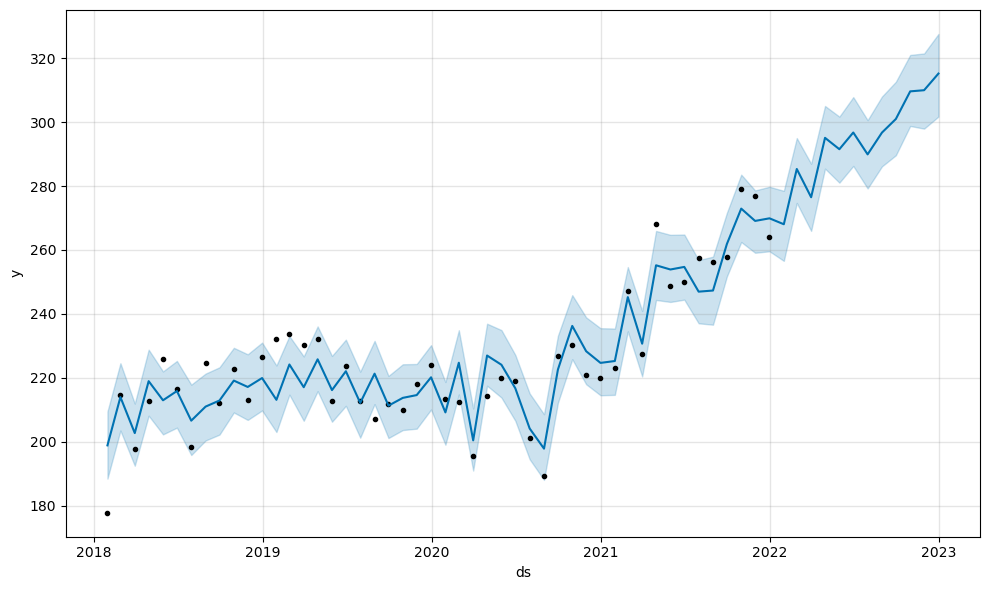

In [29]:
m = Prophet()
m.fit(df)
future = m.make_future_dataframe(periods=12, freq='M')
forecast = m.predict(future)


fig1 = m.plot(forecast)
fig1.savefig('prophet_forecast.png')
print('Saved prophet_forecast.png')

# ARIMA using statsmodels

In [32]:
import statsmodels.api as sm

C:\Users\Neliswa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Neliswa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\Neliswa\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Saved arima_forecast.png


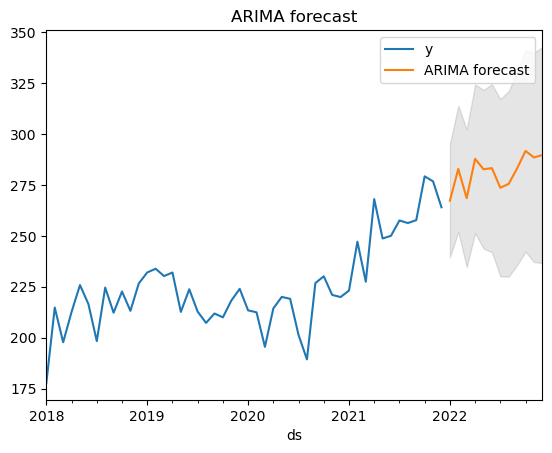

In [34]:
df_arima = df.set_index('ds')
model = sm.tsa.SARIMAX(df_arima['y'], order=(1,1,1), seasonal_order=(1,1,1,12))
res = model.fit(disp=False)
pred = res.get_forecast(steps=12)
pred_ci = pred.conf_int()

ax = df_arima.plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='ARIMA forecast')
ax.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='k', alpha=0.1)
ax.legend()
plt.title('ARIMA forecast')
plt.savefig('arima_forecast.png')
print('Saved arima_forecast.png')